# **Mini-projet n°2 : Conditional VAEs**

L'objectif de ce mini-projet est de construire et entraîner un Conditional Variational Auto Encoder sur le dataset FashionMNIST qui contient des images d'habits en noir et blanc de taille 28x28 pixels. Ici, le résultat recherché n'est pas de la classification ou de la prédiction, mais plutôt de la génération de nouveaux échantillons.

# I - Introduction aux modèles

## A - Auto Encoders

Les Auto Encoders (AE) sont un type de réseau de neurones que l'on peut décomposer en 3 parties comme montré sur le schéma suivant : 

<p align="center">
  <img src="Autoencoder.png" width="350">
</p>

Les AE projettent un objet d’entrée dans un espace latent de dimension réduite, avant de tenter d’en reconstruire une approximation en sortie.

Comme tout réseau de neurones, un autoencodeur est composé de plusieurs couches. Elles sont de la forme suivante :

$
h' = f \Big( W h + b \Big)
$

où la couche prend en entrée un vecteur $h$ (provenant de la couche précédente) et renvoie un nouveau vecteur $h'$.

$f$ est appelé fonction d'activation, $W$ est matrice de poids de la couche, et $b$ est vecteur de biais de la couche.

Pour l'entraînement, on utilise une fonction de perte qui permet de calculer l'écart de reconstruction entre l'entrée de l'AE et la sortie. On peur par exemple se servir de la Mean Square Error (MSE) :

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

On peut ensuite effectuer une rétropropagation pour calculer les gradients de chaque couche, et mettre à jour les valeurs des paramètres avec un algorithme d'optimisation choisi.

Ainsi, un AE permet en quelque sorte de compresser l'information dans l'espace latent. Mais cet espace latent n’est pas structuré : les points proches dans l’espace latent ne garantissent pas des reconstructions similaires, ce qui en fait un très mauvais générateur d'images.

## B - Variational Auto Encoders

La principale différence entre les Variational Auto Encoders (VAE) et les AE classiques réside dans le fait que les VAE contraignent leur espace latent à avoir une certaine forme. Dans un AE classique, deux points proches dans l’espace latent peuvent produire deux reconstructions très différentes.
Un VAE essaye de forcer son espace latent à suivre une distribution gaussienne. L’idée derrière un VAE est d’attribuer à chaque entrée qu'on lui donne une moyenne ${\mu}$ et une variance ${\sigma^{2}}$ dans l’espace latent, plutôt qu’une position fixe.

Concrètement, cela passe par l'implémentation de deux "têtes" à la sortie de l'encodeur, une tête pour $\mu$ et une tête pour $log(\sigma^{2})$ (on utilise le log pour des raisons de stabilité notamment). Chaque tête est en fait une couche supplémentaire qui prend en entrée la sortie de l'encodeur et qui ressort un vecteur de la taille de l'espace latent.

Il faut ensuite adapter la fonction de perte afin que la distribution latente apprise soit proche d’une loi gaussienne. On ajoute un terme à la fonction de perte classique appelé terme de Kullback-Leibler :

$$
\text{KL}= -\frac{1}{2} \sum_{i=1}^{d} \Big( 1 + \log(\sigma_i^2) - \mu_i^2 - \sigma_i^2 \Big)
$$

où l'espace latent a une dimension $d$.

Ainsi, la fonction de perte (si on garde la MSE comme pour l'exemple précédent) devient : 

$$
\mathcal{L}_{\text{VAE}} = MSE + \beta KL
$$

Le paramètre $\beta$ permet de quantifier à quel point on veut "forcer" l'espace latent à être gaussien.

Avec cette configuration, les VAE peuvent permettre de générer une nouvelle image après entraînement. Par contre, ils ne permettent pas de choisir entre plusieurs classes d'images comme dans le dataset FashionMNIST car ils ne fonctionnent que sur un type d'image.

## C - Conditional Variational Encoders

Les Conditional Variational Autoencoders (CVAE) fonctionnent comme les VAE classiques, à la différence près que l’on fournit au réseau la classe $y$ de l’objet en entrée. Concrètement, cela se fait en injectant un vecteur dit one-hot, composé de 0 sauf une de ses composantes qui vaut 1, correspondant à la classe de l’objet. Cette injection peut se faire soit par concaténation du vecteur one-hot à l’objet d’entrée avant l’encodeur et le décodeur, soit par ajout à une couche intermédiaire du réseau, de la manière suivante :

$$ h^{(n)} = \sigma \Big( W_h^{(n)} \, h^{(n-1)} + W_y \, y + b^{(n)} \Big) $$

En soi, la fonction de perte reste la même, mais on peut dire qu'elle est conditionnée par la classe $y$ alors que ce n'était pas le cas pour les VAE.

Cette information de classe permet au CVAE de générer des images contrôlées selon la classe souhaitée.

Cette introduction sur les différents types d'Auto Encoders étant faite, on pourra commencer à créer notre propre CVAE pour générer des images par classe d'habits.

# II - Premiers essais

## A - Importation de librairies et téléchargement du dataset

In [47]:
import numpy as np
import random
import torchvision
from torchvision import datasets, transforms
import torch
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
import json

transform = transforms.Compose([transforms.ToTensor()])

# Ensembles d'entraînement et de validation
dataset = datasets.FashionMNIST(root='data', train=True, transform=transform, download=True) 
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Ensemble de test
test_dataset = datasets.FashionMNIST(root='data', train=False, transform=transform, download=True)

## B - Un premier CVAE

Pour commencer, on consruit un CVAE assez basique qui sera conditionné sur les 10 classes différentes issues de FashionMNIST. 

L'encodeur et le décodeur auront 3 couches, et la classe sera concaténée avec un vecteur one-hot à l'entrée de chacun.

L'encodeur prend en entrée un vecteur de taille 794 (image de taille 28x28 + vecteur one-hot de taille 10). Il réduit ensuite progessivement la dimension jusqu'à une taille de 128. 

Le vecteur réduit passe ensuite par les deux têtes pour produire les deux vecteurs $\mu$ et $log(\sigma^{2})$.

La taille de l'espace latent n'est pas définie, car elle sera ammenée à changer, disons donc qu'elle est de $d$.

On échantillone ensuite un point dans l'espace latent afin d'introduire dans le décodeur un vecteur de taille $d$ + 10 (échantillon latent de taille $d$ + vecteur one-hot de taille 10). Le décodeur agrandit progressivement la dimension jusqu'à atteindre 784. Notre image est ainsi reconstruite.

La fonction d'activation utilisée sur chaque couche est la ReLU $(ReLU(x)=max(0,x))$, saif pour la dernière couche du décodeur qui utilise une sigmoïde $(Sigmoïd(x) = \frac{1}{1 + e^{-x}})$, afin de s'assurer que la valeur du dernier pixel reconstruit soit entre 0 et 1.

### 1 - Construction

In [65]:
class SimpleCVAE(nn.Module):
    def __init__(self,  latent_dim, input_dim=28*28, num_classes=10, hidden_dim1=512, hidden_dim2=256, hidden_dim3=128):
        super(SimpleCVAE, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # Encodeur
        self.encoder_fc1 = nn.Linear(input_dim + num_classes, hidden_dim1)
        self.encoder_fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.encoder_fc3 = nn.Linear(hidden_dim2, hidden_dim3)
        
        # Têtes mu et logvar
        self.fc_mu = nn.Linear(hidden_dim3, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim3, latent_dim)
        
        # Décodeur
        self.decoder_fc1 = nn.Linear(latent_dim + num_classes, hidden_dim3)
        self.decoder_fc2 = nn.Linear(hidden_dim3, hidden_dim2)
        self.decoder_fc3 = nn.Linear(hidden_dim2, hidden_dim1)
        
        # Sortie
        self.decoder_out = nn.Linear(hidden_dim1, input_dim)
        
    def encode(self, x, c):
        x = torch.cat([x, c], dim=1)
        x = F.relu(self.encoder_fc1(x))
        x = F.relu(self.encoder_fc2(x))
        x = F.relu(self.encoder_fc3(x))
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, c):
        x = torch.cat([z, c], dim=1)
        x = F.relu(self.decoder_fc1(x))
        x = F.relu(self.decoder_fc2(x))
        x = F.relu(self.decoder_fc3(x))
        x = torch.sigmoid(self.decoder_out(x))
        return x
    
    def forward(self, x, labels):
        x = x.view(x.size(0), -1)
        c = torch.zeros(x.size(0), self.num_classes, device=x.device)
        c.scatter_(1, labels.view(-1,1), 1)    
        mu, logvar = self.encode(x, c)
        z = self.sample(mu, logvar)
        recon_x = self.decode(z, c)
        return recon_x, mu, logvar

### 2 - Entraînement

Pour l'instant, les hyperparamètres sont choisis arbitrairement. L'objectif est d'avoir un premier résultat et de mieux appréhender le fonctionnement d'un CVAE.

In [66]:
# Utiliser GPU si disponible
device = "cuda" if torch.cuda.is_available() else "cpu"

# Hyperparamètres
batch_size = 128
lr = 1e-3
epochs = 10
beta = 1
latent_dim = 10

# Fonction de perte
def loss_function(recon_x, x, mu, logvar, beta):
    # MSE
    mse = nn.functional.mse_loss(recon_x, x.view(x.size(0), -1), reduction='sum')
    # KL
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + beta * kl

# Chargement des ensembles d'entraînement et de validation
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Initialisation du modèle
model = SimpleCVAE(latent_dim=latent).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

# Boucle d'entraînement
for epoch in range(1, epochs+1):
    model.train()
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(train_loader):
        data, labels = data.to(device), labels.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(data, labels)
        loss = loss_function(recon, data, mu, logvar, beta)
        loss.backward()
        optimizer.step()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, labels in val_loader:
            data, labels = data.to(device), labels.to(device)
            recon, mu, logvar = model(data, labels)
            
    print(f"Epoch numéro {epoch} terminé.")

Epoch numéro 1 terminé.
Epoch numéro 2 terminé.
Epoch numéro 3 terminé.
Epoch numéro 4 terminé.
Epoch numéro 5 terminé.
Epoch numéro 6 terminé.
Epoch numéro 7 terminé.
Epoch numéro 8 terminé.
Epoch numéro 9 terminé.
Epoch numéro 10 terminé.


## C - Premiers résultats

### 1 - Espace latent

On peut commencer par visualiser l'espace latent, en faisant passer chaque image de l'ensemble de test dans le CVAE, et en récupérant la valeur $\mu$ qui lui a été assignée.

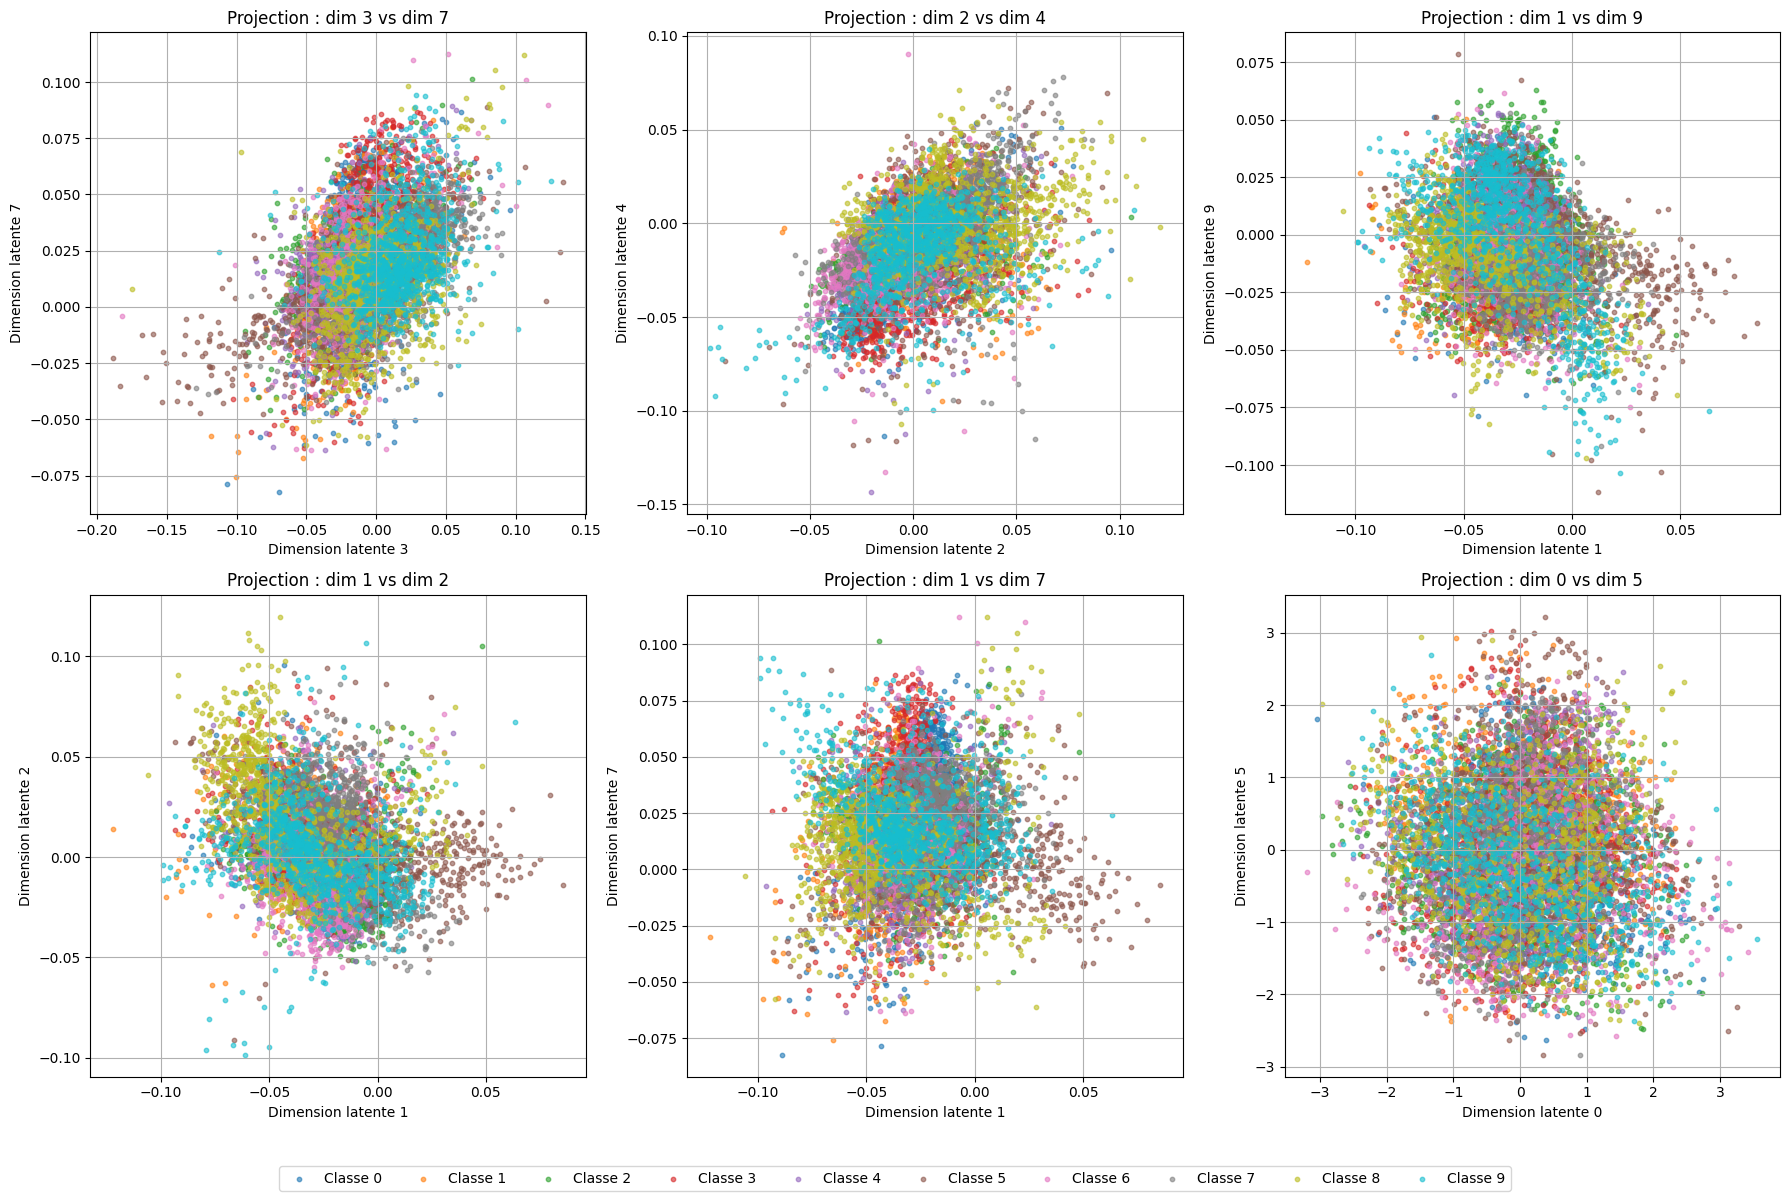

In [67]:
# Récupération des images de l'ensemble de test
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Récupération des points latents de chaque image  
model.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        _, mu, _ = model(data, labels) 
        all_mu.append(mu)
        all_labels.append(labels)

all_mu = torch.cat(all_mu, dim=0).cpu().numpy()         
all_labels = torch.cat(all_labels, dim=0).cpu().numpy()

# Tirage aléatoire de 6 paires de dimensions parmi les 10

latent_dims = list(range(10))
pairs = random.sample(
    [(i, j) for i in latent_dims for j in latent_dims if i < j],
    6
)

plt.figure(figsize=(18, 12))

for k, (d1, d2) in enumerate(pairs):
    plt.subplot(2, 3, k + 1)
    
    for cls in range(10):
        idx = all_labels == cls
        plt.scatter(
            all_mu[idx, d1],
            all_mu[idx, d2],
            s=10,
            alpha=0.6,
            label=f"Classe {cls}"
        )
    
    plt.xlabel(f"Dimension latente {d1}")
    plt.ylabel(f"Dimension latente {d2}")
    plt.title(f"Projection : dim {d1} vs dim {d2}")
    plt.grid(True)

handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc="lower center", ncol=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### 2 - Reconstruction d'image

On peut remarquer une certaine séparation entre quelques unes des classes sur cette projection 2D, mais le reste est plutôt confus car l'espace latent fait 10 dimensions. Visualisons maintenant la capacité de notre CVAE à reconstruire des images piochées dans l'ensemble de test.

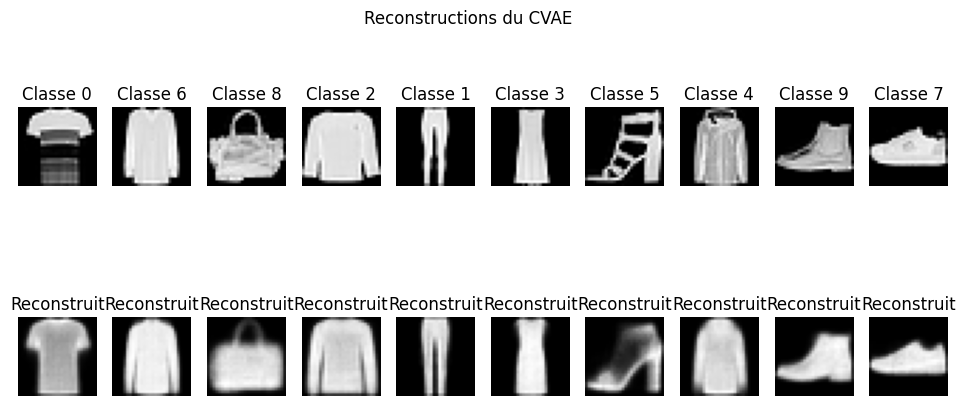

In [68]:
# Récupérer toutes les données du test set

model.eval()
all_data = []
all_labels = []

for data, labels in test_loader:
    all_data.append(data)
    all_labels.append(labels)
all_data = torch.cat(all_data, dim=0)
all_labels = torch.cat(all_labels, dim=0)

# Choisir 5 images aléatoires de classes différentes
chosen_classes = []
chosen_indices = []

np.random.seed(42)
while len(chosen_classes) < 10:
    idx = np.random.randint(0, len(all_labels))
    label = all_labels[idx].item()
    if label not in chosen_classes:
        chosen_classes.append(label)
        chosen_indices.append(idx)

images = all_data[chosen_indices].to(device)
labels = all_labels[chosen_indices].to(device)

# Reconstruction de ces 10 images
with torch.no_grad():
    recon, _, _ = model(images, labels)

# Affichage de la reconstruction
fig, axes = plt.subplots(2, 10, figsize=(12,5))
for i in range(10):

    axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Classe {labels[i].item()}")
    
    axes[1, i].imshow(recon[i].cpu().view(28,28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Reconstruit")

plt.suptitle("Reconstructions du CVAE")
plt.show()

### 3 - Génération de nouvelles images

On remarque que notre modèle reconstruit plutôt bien les images, même si elles sont un peu floues. Testons maintenant sa capacité à générer de nouvelles images.

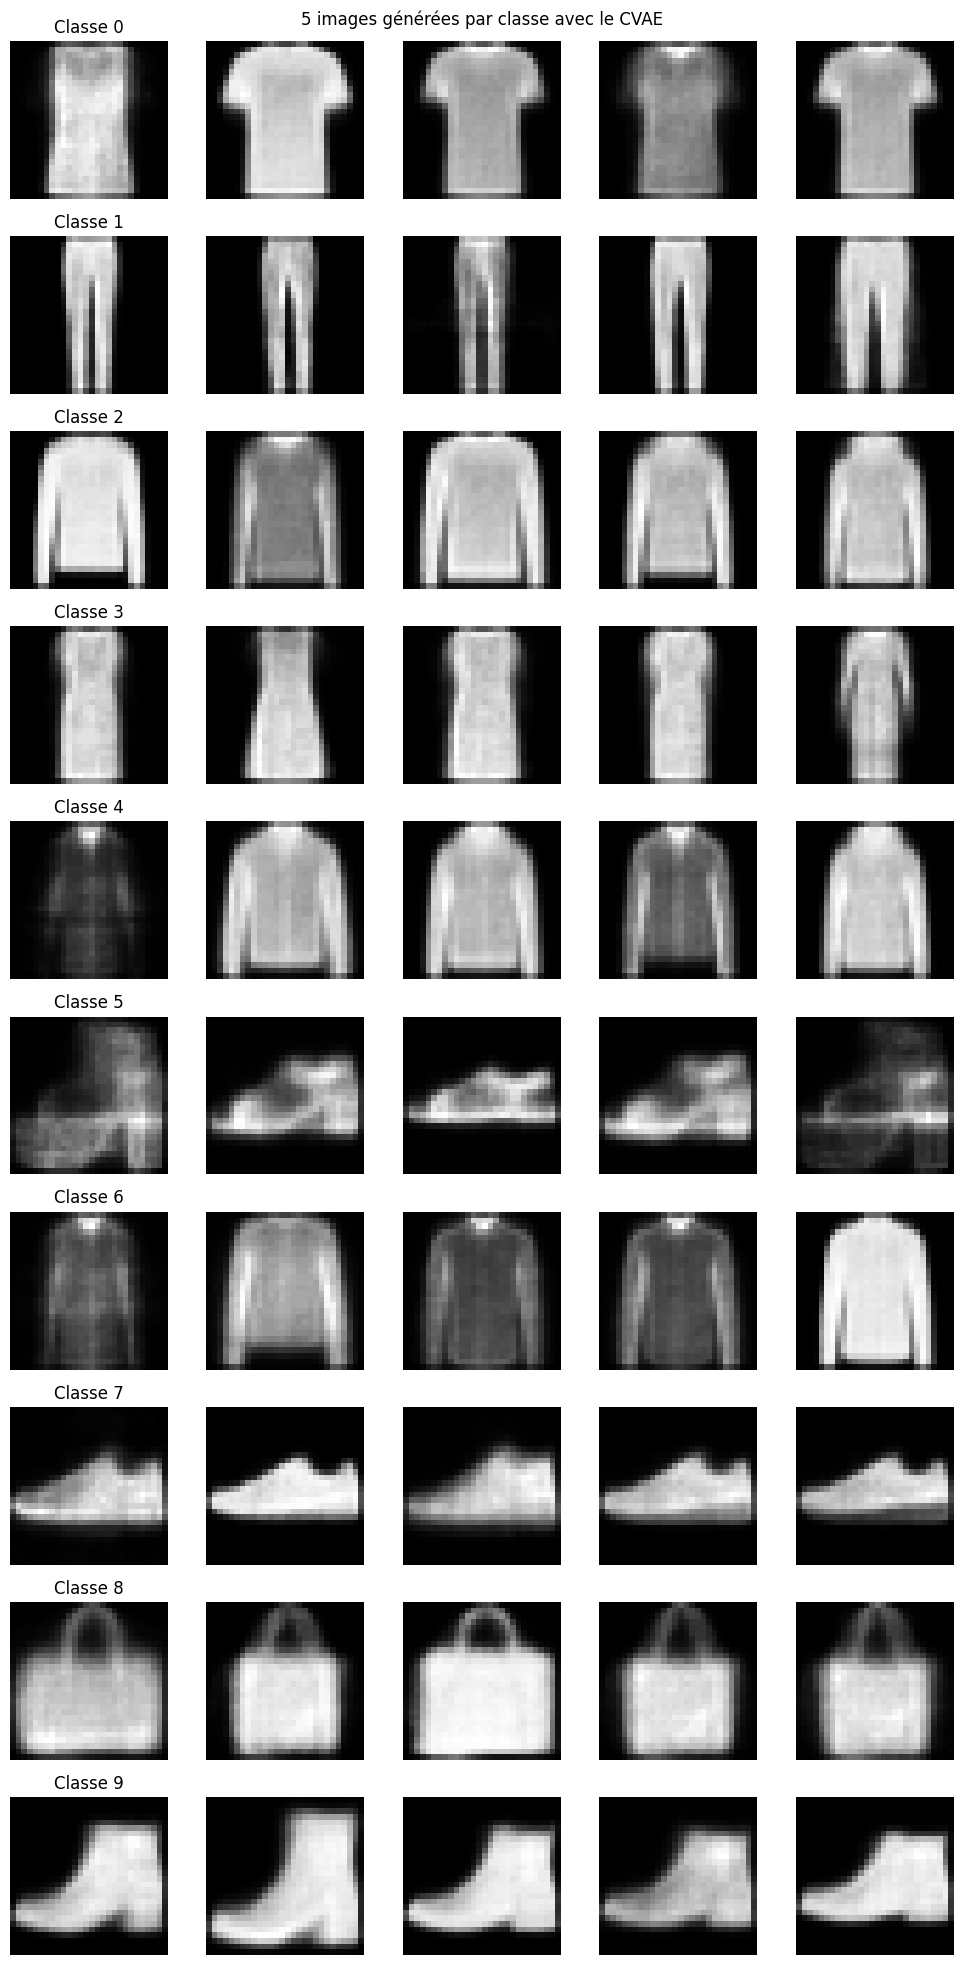

In [69]:
# Génération de points aléatoires dans l'espace latent et génération à partir de ces points là
model.eval()
num_classes = 10
samples_per_class = 5
latent_dim = model.latent_dim

all_generated = []

with torch.no_grad():
    for cls in range(num_classes):
        # Vecteur one-hot pour cette classe
        c = torch.zeros(samples_per_class, num_classes, device=device)
        c[:, cls] = 1      
        # Vecteur aléatoires dans l'espace latent
        z = torch.randn(samples_per_class, latent_dim, device=device)
        # Génération
        generated = model.decode(z, c)
        all_generated.append(generated)

# Affichage
all_generated = torch.cat(all_generated, dim=0)

fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(samples_per_class*2, num_classes*2))
for i in range(num_classes):
    for j in range(samples_per_class):
        idx = i*samples_per_class + j
        axes[i, j].imshow(all_generated[idx].cpu().view(28,28), cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(f"Classe {i}")

plt.suptitle("5 images générées par classe avec le CVAE")
plt.tight_layout()
plt.show()

On remarque que à part quelques images qui sont un peu sombres et d'autres à qui il manque des détails, notre modèle arrive quand même à générer des images ressemblantes pour la plupart. On peut maintenant essayer de jouer avec la structure et les hyperparamètres de notre modèle afin d'avoir des images encore mieux générées.

# III - Optimisation du modèle

Dans cette partie, on va essayer de faire varier les hyperparamètres à notre disposition afin d'obtenir la meilleure génération d'images possible. En l’absence de référence objective pour évaluer la qualité des images générées, la perte de reconstruction est utilisée comme indicateur de référence pour la sélection des hyperparamètres. Cette évaluation quantitative sera complétée par une analyse visuelle des images générées par le modèle optimal, ainsi que d'une étude de son espace latent.

## A - Optimisation des hyperparamètres

Tout d'abord dans cette partie nous utiliserons comme premier terme de la fonction de perte la Binary Cross Entropy (BCE). En effet, nous avons pu remarquer lors de nos premiers tests que les images étaient parfois un peu floues. La BCE nous permet d'obtenir des images plus nettes car elle pénalise si un pixel n'est pas proche de 0 ou 1, tandis que la MSE est plus "lisse" et pénalise moins.

Pour des raisons de temps de calcul, nous allons tester trois valeurs par hyperparamètre, sauf pour le nombre d'epochs. Cela fera donc 81 combinaisons d'hyperparamètres qui vont être testées. 

In [39]:
# Hyperparamètres à tester 
batch_sizes = [64, 128, 256]
lrs = [1e-2, 1e-3, 1e-4]
betas = [0.5, 1, 2]
latents = [2, 5, 10]
epochs = 10 

# Nouvelle fonction de perte
def loss_function(recon_x, x, mu, logvar, beta):
    x = x.view(x.size(0), -1)
    # BCE 
    bce = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    # KL 
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + beta * kl

results = []
best_val_loss = float('inf')
best_hyperparams = None
best_model_state = None
json_file = "grid_search_results.json"

# Grid search
for batch_size in batch_sizes:
    for lr in lrs:
        for beta in betas:
            for latent_dim in latents:
         
                train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
                
                # Initialisation modèle
                model = SimpleCVAE(latent_dim=latent_dim).to(device)
                optimizer = optim.Adam(model.parameters(), lr=lr)
                
                # Entraînement
                for epoch in range(epochs):
                    model.train()
                    for data, labels in train_loader:
                        data, labels = data.to(device), labels.to(device)
                        optimizer.zero_grad()
                        recon, mu, logvar = model(data, labels)
                        loss = loss_function(recon, data, mu, logvar, beta)
                        loss.backward()
                        optimizer.step()
                
                # Évaluation
                model.eval()
                val_loss = 0
                with torch.no_grad():
                    for data, labels in val_loader:
                        data, labels = data.to(device), labels.to(device)
                        recon, mu, logvar = model(data, labels)
                        val_loss += loss_function(recon, data, mu, logvar, beta).item()
                
                print(f"Test terminé avec batch_size={batch_size}, lr={lr}, beta={beta}, latent_dim={latent_dim} → Val Loss = {val_loss:.2f}")

                # Sauvegarde des résultats             
                config = {
                    "batch_size": batch_size,
                    "lr": lr,
                    "beta": beta,
                    "latent_dim": latent_dim,
                    "val_loss": val_loss
                }               
                results.append(config)

                with open(json_file, "w") as f:
                    json.dump(results, f, indent=4)
                
                # Vérifier si c'est le meilleur modèle
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_hyperparams = config
                    best_model_state = model.state_dict()

print("Meilleur modèle trouvé !")
print(best_hyperparams)
print(f"Val Loss = {best_val_loss:.2f}")
output = {
    "all_results": results,
    "best_model": {
        "hyperparams": best_hyperparams,
        "val_loss": best_val_loss
    }
}
with open(json_file, "w") as f:
    json.dump(output, f, indent=4)
torch.save(best_model_state, "best_cvae.pth")
print("Poids sauvegardés dans best_cvae.pth")

Test terminé avec batch_size=64, lr=0.01, beta=0.5, latent_dim=2 → Val Loss = 3009086.80
Test terminé avec batch_size=64, lr=0.01, beta=0.5, latent_dim=5 → Val Loss = 2947322.78
Test terminé avec batch_size=64, lr=0.01, beta=0.5, latent_dim=10 → Val Loss = 3022972.92
Test terminé avec batch_size=64, lr=0.01, beta=1, latent_dim=2 → Val Loss = 3076580.77
Test terminé avec batch_size=64, lr=0.01, beta=1, latent_dim=5 → Val Loss = 3064893.13
Test terminé avec batch_size=64, lr=0.01, beta=1, latent_dim=10 → Val Loss = 3070462.47
Test terminé avec batch_size=64, lr=0.01, beta=2, latent_dim=2 → Val Loss = 3126131.11
Test terminé avec batch_size=64, lr=0.01, beta=2, latent_dim=5 → Val Loss = 3306617.01
Test terminé avec batch_size=64, lr=0.01, beta=2, latent_dim=10 → Val Loss = 3139557.81
Test terminé avec batch_size=64, lr=0.001, beta=0.5, latent_dim=2 → Val Loss = 2974304.64
Test terminé avec batch_size=64, lr=0.001, beta=0.5, latent_dim=5 → Val Loss = 2835168.02
Test terminé avec batch_size

On voit donc que dans notre cas, les hyperparamètres optimaux sont un batch size de 64, un learning rate de 0.001, le terme $\beta$ à 0.5, et une dimension latente de taille 5.

Pour ne pas avoir à réentraîner le modèle, nous avons sauvegardé ses poids dans un fichier .pth, pour pouvoir le réutiliser instantanément pour de la reconstruction ou de la génération.

## B - Résultats du modèle optimal

On commence par charger le modèle optimal depuis le fichier .pth.

In [71]:
# Chargement du modèle optimal
bestmodel = SimpleCVAE(latent_dim=5).to(device)
bestmodel.load_state_dict(torch.load("best_cvae.pth", map_location=device))

<All keys matched successfully>

### 1 - Espace latent

Ici, notre espace latent est de plus petite dimension que précédemment. Essayons de le visualiser.

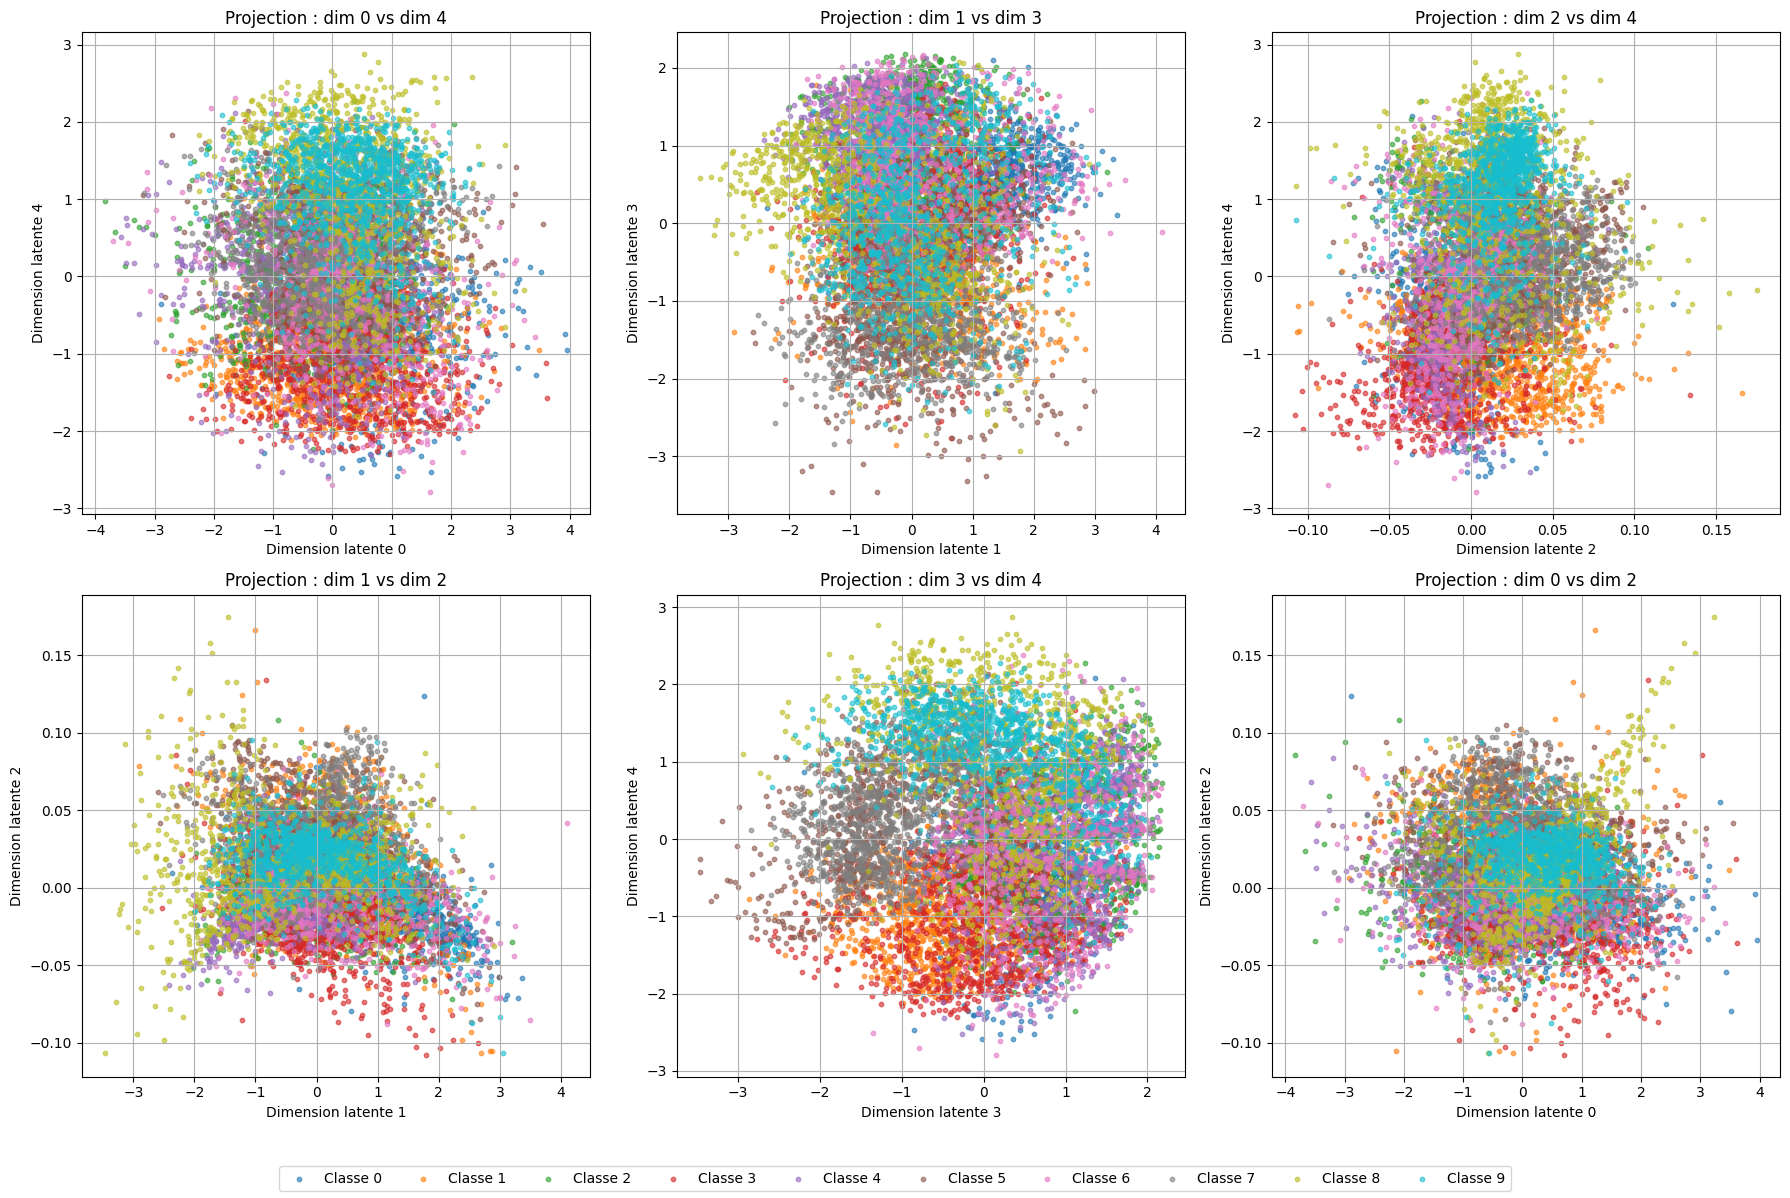

In [72]:
# Récupération des points latents
bestmodel.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        labels = labels.to(device)

        data_flat = data.view(data.size(0), -1)

        c = torch.zeros(data.size(0), bestmodel.num_classes).to(device)
        c.scatter_(1, labels.view(-1, 1), 1)

        mu, logvar = bestmodel.encode(data_flat, c)

        all_mu.append(mu)
        all_labels.append(labels)

all_mu = torch.cat(all_mu, dim=0).cpu().numpy()
all_labels = torch.cat(all_labels, dim=0).cpu().numpy()

# Tirage aléatoire de 6 paires de dimensions parmi les 5

latent_dims = list(range(5))
pairs = random.sample(
    [(i, j) for i in latent_dims for j in latent_dims if i < j],
    6
)

plt.figure(figsize=(18, 12))

for k, (d1, d2) in enumerate(pairs):
    plt.subplot(2, 3, k + 1)
    
    for cls in range(10):
        idx = all_labels == cls
        plt.scatter(
            all_mu[idx, d1],
            all_mu[idx, d2],
            s=10,
            alpha=0.6,
            label=f"Classe {cls}"
        )
    
    plt.xlabel(f"Dimension latente {d1}")
    plt.ylabel(f"Dimension latente {d2}")
    plt.title(f"Projection : dim {d1} vs dim {d2}")
    plt.grid(True)

handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc="lower center", ncol=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

On peut relancer plusieurs fois le code d'affichage pour visualiser les différentes dimensions. Globalement, on remarque des nuages distincts par classe, même si la différence n'est pas flagrante par rapport au premier modèle. 

### 2 - Reconstruction

Essayons de reconstruire les mêmes images que précédemment.

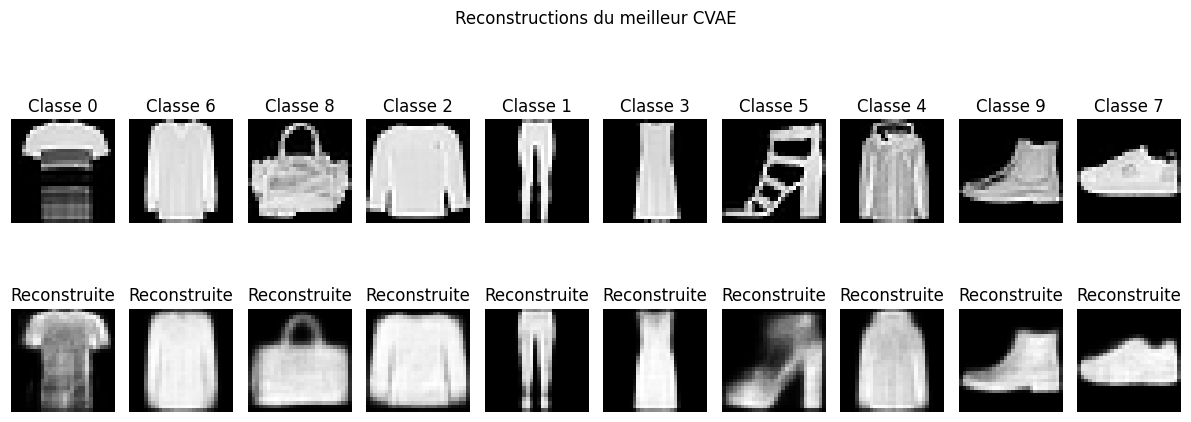

In [74]:
# Récupération des images de l'ensemble de test
all_data = []
all_labels = []

for data, labels in test_loader:
    all_data.append(data)
    all_labels.append(labels)

all_data = torch.cat(all_data, dim=0)
all_labels = torch.cat(all_labels, dim=0)

# Choisir 10 images aléatoires de classes différentes
chosen_classes = []
chosen_indices = []

np.random.seed(42)

while len(chosen_classes) < 10:
    idx = np.random.randint(0, len(all_labels))
    label = all_labels[idx].item()
    if label not in chosen_classes:
        chosen_classes.append(label)
        chosen_indices.append(idx)

images = all_data[chosen_indices].to(device)
labels = all_labels[chosen_indices].to(device)

# Reconstruction
with torch.no_grad():
    bestrecon, _, _ = bestmodel(images, labels)

# Affichage
fig, axes = plt.subplots(2, 10, figsize=(12, 5))

for i in range(10):
    # Image originale
    axes[0, i].imshow(images[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Classe {labels[i].item()}")

    # Image reconstruite
    axes[1, i].imshow(bestrecon[i].cpu().view(28, 28), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Reconstruite")

plt.suptitle("Reconstructions du meilleur CVAE")
plt.tight_layout()
plt.show()

On remarque une reconstruction légèrement moins floue que pour le premier modèle.

### 3 - Génération

Il est maintenant temps de générer de nouvelles images avec le modèle optimisé

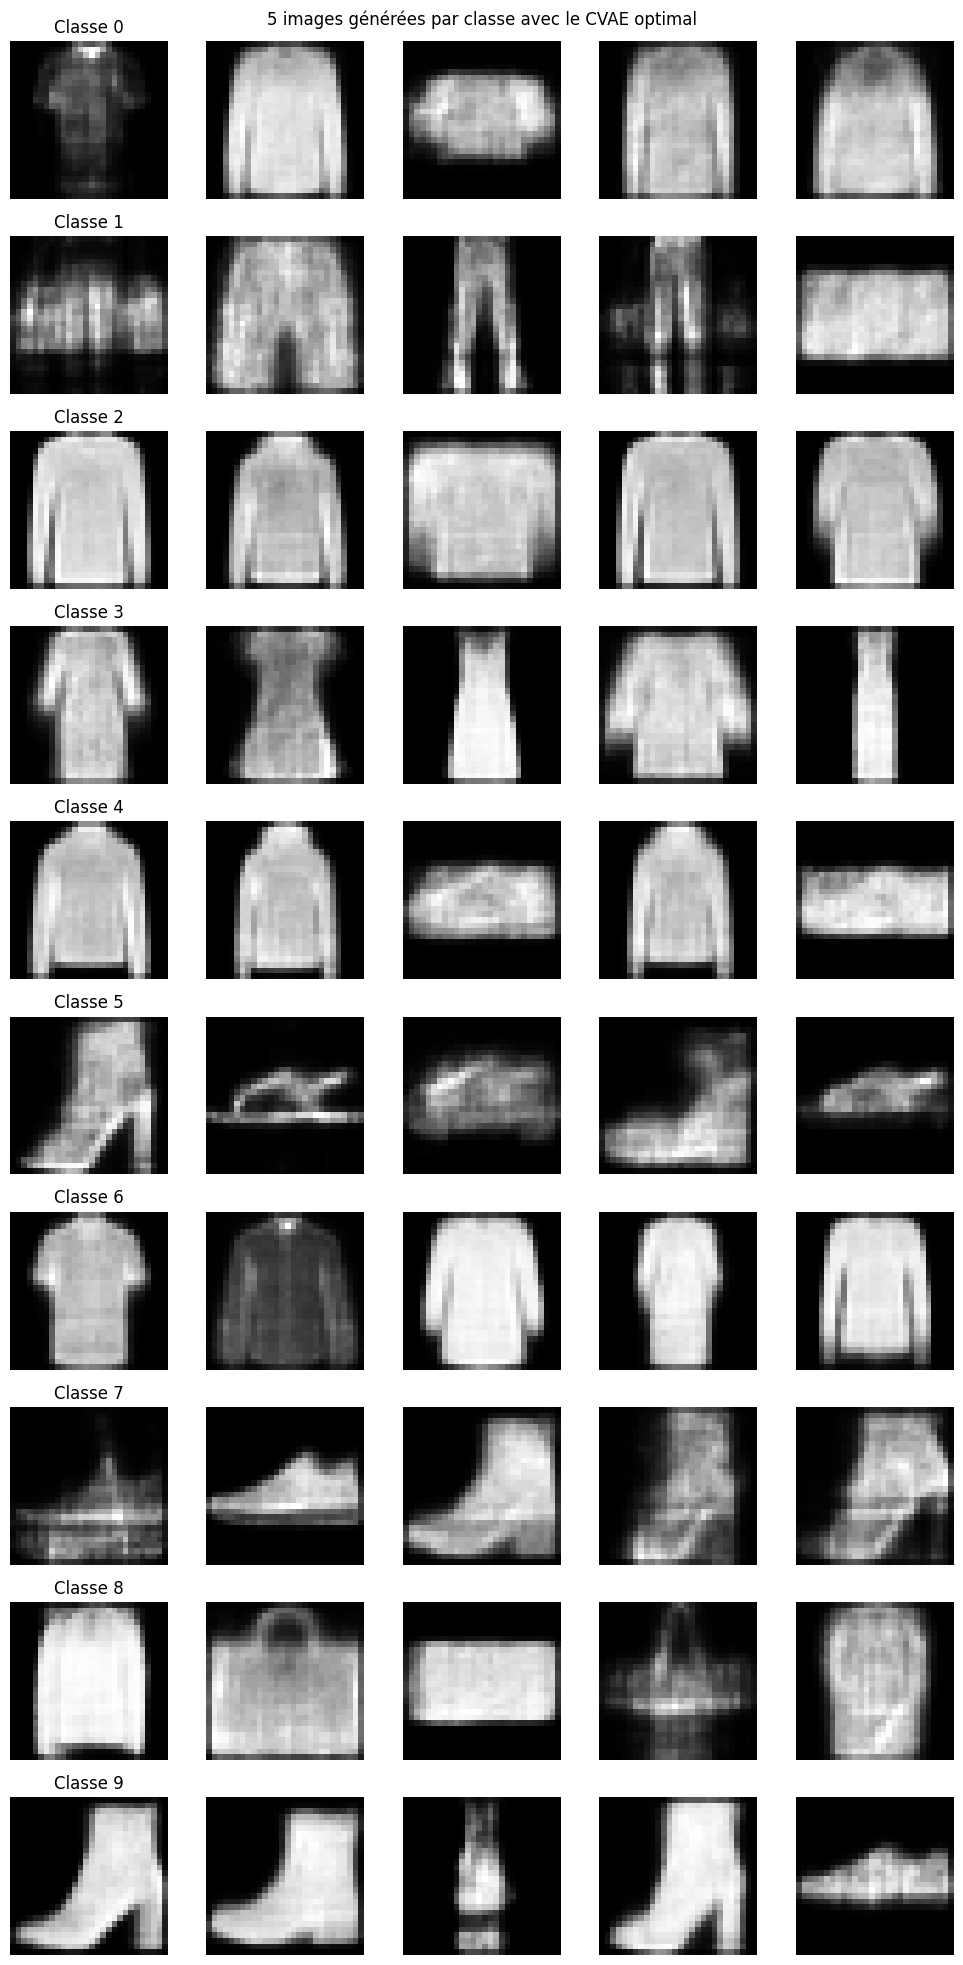

In [81]:
# Génération de points aléatoires dans l'espace latent et génération à partir de ces points là
bestmodel.eval()
num_classes = 10
samples_per_class = 5
latent_dim = bestmodel.latent_dim

all_generated = []

with torch.no_grad():
    for cls in range(num_classes):
        # Vecteur one-hot pour cette classe
        c = torch.zeros(samples_per_class, num_classes, device=device)
        c[:, cls] = 1      
        # Vecteur aléatoires dans l'espace latent
        z = torch.randn(samples_per_class, latent_dim, device=device)
        # Génération
        generated = bestmodel.decode(z, c)
        all_generated.append(generated)

# Affichage
all_generated = torch.cat(all_generated, dim=0)

fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(samples_per_class*2, num_classes*2))
for i in range(num_classes):
    for j in range(samples_per_class):
        idx = i*samples_per_class + j
        axes[i, j].imshow(all_generated[idx].cpu().view(28,28), cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(f"Classe {i}")

plt.suptitle("5 images générées par classe avec le CVAE optimal")
plt.tight_layout()
plt.show()

On remarque ici que la génération donne de moins bons résultats que pour le premier modèle. Ceci peut s'expliquer car on a selectionné le meilleur modèle après entraînement, donc celui qui a la meilleure capacité à reconstruire des images, mais pas forcément à en générer.

La dimension latente ici est plus petite, ce qui peut compresser des informations importantes pour la génération de détails par exemple. On peut en déduire qu'une dimension latente plus élévée permet une meilleure génération. Une plus petite permet de gagner en efficacité lors de la reconstruction.

De même, le terme $\beta$ est de 0.5 au lieu de 1, ce qui a pour effet de moins forcer l'espace latent à suivre une gaussienne. Ainsi, un point "bien" choisi aléatoirement produira une reconstruction plus fiable, tandis qu'un point trop éloigné du nuage de points produira une image sans sens. Avec un $\beta$ plus élevé, les reconstructions sont plus floues, mais auront toutes à peu près la même forme.

# IV - Conclusion

En conclusion, nous avons d’abord construit un CVAE simple avec trois couches dans l’encodeur et le décodeur, capable de générer des images conditionnées visuellement cohérentes. En optimisant les hyperparamètres pour améliorer la reconstruction, nous avons effectivement obtenu une reconstruction légèrement meilleure. Cependant, la qualité de génération à partir de points latents aléatoires s’est dégradée, car le modèle optimal pour la reconstruction est fortement calibré sur les images d’entraînement et n’explore pas uniformément l’espace latent.

Il est par contre intéressant de remarquer qu'avec un modèle simple contenant autour de 1 million de paramètres, on arrive à générer des images satisfaisantes sur les 10 classes.